In [1]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Đang sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [21]:
# ----- Cấu hình-----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0004
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 64

In [4]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [22]:
# ----- Weight init -----
def init_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ----- Generator (designed for 28x28 MNIST) -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # We'll go: 1x1 -> 7x7 -> 14x14 -> 28x28
        self.model = nn.Sequential(
            # input: (N, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),  # -> 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, nc, kernel_size=4, stride=2, padding=1, bias=False),   # -> 28x28
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        # expect z shape (N, latent_dim) or (N, latent_dim, 1, 1)
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

# ----- Discriminator (matching 28x28 input) -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7 -> 1x1
        self.model = nn.Sequential(
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),  # -> 7x7
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, 1, kernel_size=7, stride=1, padding=0, bias=False),  # -> 1x1
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)           # (N,1,1,1)
        return out.view(img.size(0), 1) # (N,1) to match your BCELoss targets

In [ ]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

generator.apply(init_weights)
discriminator.apply(init_weights)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [24]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_D: 0.0563, Loss_G: 6.1162, Time: 22.71s


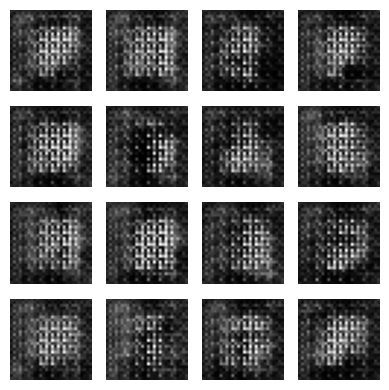

[Epoch 2/300] Loss_D: 0.0223, Loss_G: 6.1428, Time: 44.16s
[Epoch 3/300] Loss_D: 0.0578, Loss_G: 5.3551, Time: 66.45s
[Epoch 4/300] Loss_D: 0.0785, Loss_G: 4.0643, Time: 89.88s
[Epoch 5/300] Loss_D: 0.1121, Loss_G: 3.8258, Time: 116.00s
[Epoch 6/300] Loss_D: 0.1112, Loss_G: 3.8703, Time: 137.04s
[Epoch 7/300] Loss_D: 0.1645, Loss_G: 3.3456, Time: 157.73s
[Epoch 8/300] Loss_D: 0.1741, Loss_G: 3.6093, Time: 179.55s
[Epoch 9/300] Loss_D: 0.1919, Loss_G: 3.0299, Time: 203.75s
[Epoch 10/300] Loss_D: 0.1982, Loss_G: 3.1562, Time: 226.89s
[Epoch 11/300] Loss_D: 0.1823, Loss_G: 3.0682, Time: 248.79s
[Epoch 12/300] Loss_D: 0.2240, Loss_G: 2.6284, Time: 275.75s
[Epoch 13/300] Loss_D: 0.2011, Loss_G: 2.7547, Time: 322.51s
[Epoch 14/300] Loss_D: 0.2031, Loss_G: 2.8559, Time: 371.31s
[Epoch 15/300] Loss_D: 0.2420, Loss_G: 2.7774, Time: 424.24s
[Epoch 16/300] Loss_D: 0.2288, Loss_G: 2.6269, Time: 467.51s
[Epoch 17/300] Loss_D: 0.2279, Loss_G: 2.6181, Time: 524.04s
[Epoch 18/300] Loss_D: 0.2673, Loss

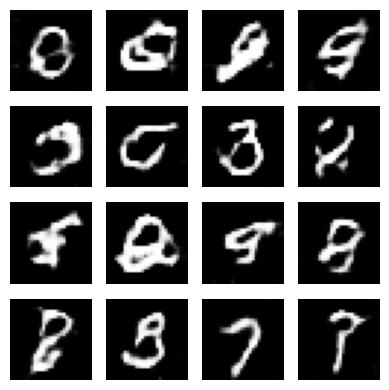

[Epoch 21/300] Loss_D: 0.2499, Loss_G: 2.8710, Time: 678.34s
[Epoch 22/300] Loss_D: 0.2369, Loss_G: 2.5074, Time: 701.91s
[Epoch 23/300] Loss_D: 0.2389, Loss_G: 2.4906, Time: 725.08s
[Epoch 24/300] Loss_D: 0.2189, Loss_G: 2.6723, Time: 780.17s
[Epoch 25/300] Loss_D: 0.2400, Loss_G: 2.5847, Time: 825.43s
[Epoch 26/300] Loss_D: 0.2391, Loss_G: 2.6297, Time: 872.07s
[Epoch 27/300] Loss_D: 0.2575, Loss_G: 2.6133, Time: 927.15s
[Epoch 28/300] Loss_D: 0.2392, Loss_G: 2.5426, Time: 980.17s
[Epoch 29/300] Loss_D: 0.2299, Loss_G: 2.4364, Time: 1034.14s
[Epoch 30/300] Loss_D: 0.2621, Loss_G: 2.5274, Time: 1087.77s
[Epoch 31/300] Loss_D: 0.2647, Loss_G: 2.7397, Time: 1140.74s
[Epoch 32/300] Loss_D: 0.2457, Loss_G: 2.5181, Time: 1179.28s
[Epoch 33/300] Loss_D: 0.2541, Loss_G: 2.6320, Time: 1205.89s
[Epoch 34/300] Loss_D: 0.2523, Loss_G: 2.4986, Time: 1226.07s
[Epoch 35/300] Loss_D: 0.2283, Loss_G: 2.6799, Time: 1245.78s
[Epoch 36/300] Loss_D: 0.2216, Loss_G: 2.6660, Time: 1266.54s
[Epoch 37/300] L

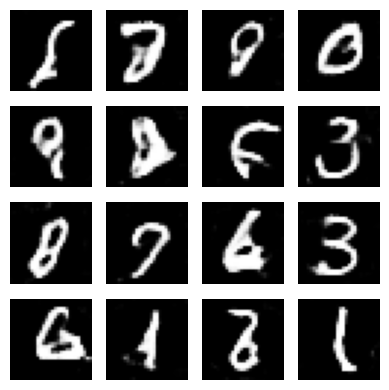

[Epoch 41/300] Loss_D: 0.2074, Loss_G: 2.5689, Time: 1520.55s
[Epoch 42/300] Loss_D: 0.1977, Loss_G: 2.6885, Time: 1577.38s
[Epoch 43/300] Loss_D: 0.2047, Loss_G: 2.7007, Time: 1635.97s
[Epoch 44/300] Loss_D: 0.1916, Loss_G: 2.7426, Time: 1673.51s
[Epoch 45/300] Loss_D: 0.1956, Loss_G: 2.8749, Time: 1697.94s
[Epoch 46/300] Loss_D: 0.2056, Loss_G: 2.9093, Time: 1723.10s
[Epoch 47/300] Loss_D: 0.2110, Loss_G: 2.9436, Time: 1749.28s
[Epoch 48/300] Loss_D: 0.2044, Loss_G: 2.9355, Time: 1767.50s
[Epoch 49/300] Loss_D: 0.2021, Loss_G: 2.9143, Time: 1789.30s
[Epoch 50/300] Loss_D: 0.1995, Loss_G: 2.9434, Time: 1809.36s
[Epoch 51/300] Loss_D: 0.1937, Loss_G: 2.9089, Time: 1830.54s
[Epoch 52/300] Loss_D: 0.2202, Loss_G: 3.0100, Time: 1852.21s
[Epoch 53/300] Loss_D: 0.1908, Loss_G: 2.9491, Time: 1874.56s
[Epoch 54/300] Loss_D: 0.1833, Loss_G: 2.8865, Time: 1898.40s
[Epoch 55/300] Loss_D: 0.1772, Loss_G: 2.8777, Time: 1924.12s
[Epoch 56/300] Loss_D: 0.1936, Loss_G: 2.9790, Time: 1948.76s
[Epoch 5

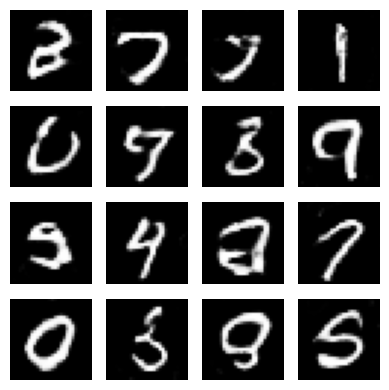

[Epoch 61/300] Loss_D: 0.1885, Loss_G: 2.9564, Time: 2060.39s
[Epoch 62/300] Loss_D: 0.1727, Loss_G: 2.9594, Time: 2084.83s
[Epoch 63/300] Loss_D: 0.1876, Loss_G: 3.0179, Time: 2109.25s
[Epoch 64/300] Loss_D: 0.1754, Loss_G: 3.1468, Time: 2134.12s
[Epoch 65/300] Loss_D: 0.2085, Loss_G: 3.2194, Time: 2159.80s
[Epoch 66/300] Loss_D: 0.1848, Loss_G: 2.9007, Time: 2182.34s
[Epoch 67/300] Loss_D: 0.1710, Loss_G: 2.9815, Time: 2204.71s
[Epoch 68/300] Loss_D: 0.1792, Loss_G: 3.0707, Time: 2227.33s
[Epoch 69/300] Loss_D: 0.1842, Loss_G: 3.0222, Time: 2249.11s
[Epoch 70/300] Loss_D: 0.1766, Loss_G: 3.0912, Time: 2272.69s
[Epoch 71/300] Loss_D: 0.1700, Loss_G: 3.0144, Time: 2294.90s
[Epoch 72/300] Loss_D: 0.1661, Loss_G: 3.1287, Time: 2318.78s
[Epoch 73/300] Loss_D: 0.1630, Loss_G: 3.0869, Time: 2343.16s
[Epoch 74/300] Loss_D: 0.1960, Loss_G: 3.1874, Time: 2364.44s
[Epoch 75/300] Loss_D: 0.1561, Loss_G: 3.1164, Time: 2386.11s
[Epoch 76/300] Loss_D: 0.1714, Loss_G: 3.1445, Time: 2407.56s
[Epoch 7

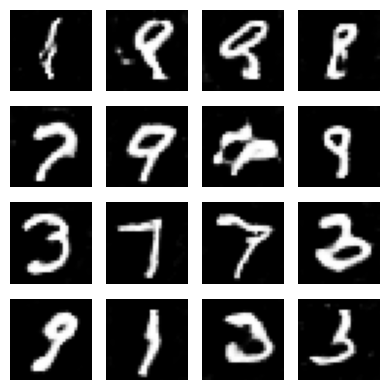

[Epoch 81/300] Loss_D: 0.1820, Loss_G: 3.1915, Time: 2513.40s
[Epoch 82/300] Loss_D: 0.1569, Loss_G: 3.1427, Time: 2533.01s
[Epoch 83/300] Loss_D: 0.1759, Loss_G: 3.2087, Time: 2552.04s
[Epoch 84/300] Loss_D: 0.1786, Loss_G: 3.3197, Time: 2571.42s
[Epoch 85/300] Loss_D: 0.1791, Loss_G: 3.1193, Time: 2591.14s
[Epoch 86/300] Loss_D: 0.1735, Loss_G: 3.2260, Time: 2610.29s
[Epoch 87/300] Loss_D: 0.1595, Loss_G: 3.1631, Time: 2641.69s
[Epoch 88/300] Loss_D: 0.1605, Loss_G: 3.1958, Time: 2700.76s
[Epoch 89/300] Loss_D: 0.1685, Loss_G: 3.1955, Time: 2736.01s
[Epoch 90/300] Loss_D: 0.1809, Loss_G: 3.2150, Time: 2759.57s
[Epoch 91/300] Loss_D: 0.1836, Loss_G: 3.2602, Time: 2782.88s
[Epoch 92/300] Loss_D: 0.1649, Loss_G: 3.1281, Time: 2804.82s
[Epoch 93/300] Loss_D: 0.1666, Loss_G: 3.1713, Time: 2826.53s
[Epoch 94/300] Loss_D: 0.2175, Loss_G: 3.3620, Time: 2851.42s
[Epoch 95/300] Loss_D: 0.1803, Loss_G: 3.2135, Time: 2876.86s
[Epoch 96/300] Loss_D: 0.1618, Loss_G: 3.1174, Time: 2901.10s
[Epoch 9

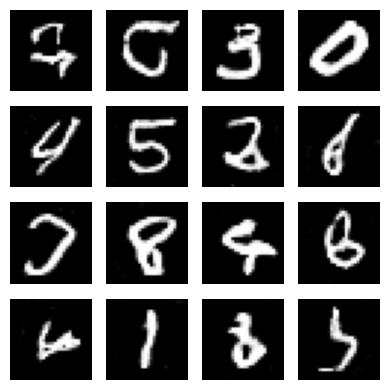

[Epoch 101/300] Loss_D: 0.1640, Loss_G: 3.1539, Time: 3018.53s
[Epoch 102/300] Loss_D: 0.1703, Loss_G: 3.2407, Time: 3043.38s
[Epoch 103/300] Loss_D: 0.1882, Loss_G: 3.2610, Time: 3067.74s
[Epoch 104/300] Loss_D: 0.2054, Loss_G: 3.2136, Time: 3091.41s
[Epoch 105/300] Loss_D: 0.1901, Loss_G: 3.2134, Time: 3114.90s
[Epoch 106/300] Loss_D: 0.1628, Loss_G: 3.1754, Time: 3137.69s
[Epoch 107/300] Loss_D: 0.1938, Loss_G: 3.1956, Time: 3159.60s
[Epoch 108/300] Loss_D: 0.1996, Loss_G: 3.2019, Time: 3181.56s
[Epoch 109/300] Loss_D: 0.1863, Loss_G: 3.1516, Time: 3205.78s
[Epoch 110/300] Loss_D: 0.1894, Loss_G: 3.0795, Time: 3230.42s
[Epoch 111/300] Loss_D: 0.1841, Loss_G: 3.0699, Time: 3255.31s
[Epoch 112/300] Loss_D: 0.1926, Loss_G: 3.1251, Time: 3278.31s
[Epoch 113/300] Loss_D: 0.1968, Loss_G: 3.1608, Time: 3301.59s
[Epoch 114/300] Loss_D: 0.1964, Loss_G: 3.1262, Time: 3323.94s
[Epoch 115/300] Loss_D: 0.1936, Loss_G: 3.0788, Time: 3346.15s
[Epoch 116/300] Loss_D: 0.2157, Loss_G: 3.1758, Time: 3

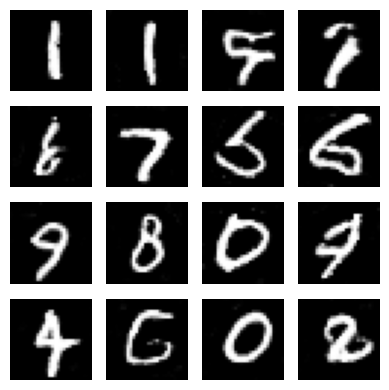

[Epoch 121/300] Loss_D: 0.1966, Loss_G: 3.0335, Time: 3489.99s
[Epoch 122/300] Loss_D: 0.1987, Loss_G: 3.0253, Time: 3512.54s
[Epoch 123/300] Loss_D: 0.1930, Loss_G: 3.0301, Time: 3533.99s
[Epoch 124/300] Loss_D: 0.2075, Loss_G: 3.0424, Time: 3556.48s
[Epoch 125/300] Loss_D: 0.2177, Loss_G: 3.0795, Time: 3581.60s
[Epoch 126/300] Loss_D: 0.2208, Loss_G: 2.9847, Time: 3606.39s
[Epoch 127/300] Loss_D: 0.1942, Loss_G: 2.9277, Time: 3630.83s
[Epoch 128/300] Loss_D: 0.2155, Loss_G: 3.0071, Time: 3653.44s
[Epoch 129/300] Loss_D: 0.1951, Loss_G: 3.0205, Time: 3676.18s
[Epoch 130/300] Loss_D: 0.2292, Loss_G: 3.0118, Time: 3698.23s
[Epoch 131/300] Loss_D: 0.2072, Loss_G: 2.9807, Time: 3721.42s
[Epoch 132/300] Loss_D: 0.2168, Loss_G: 3.0070, Time: 3745.09s
[Epoch 133/300] Loss_D: 0.2078, Loss_G: 3.0328, Time: 3770.20s
[Epoch 134/300] Loss_D: 0.2270, Loss_G: 3.0012, Time: 3795.47s
[Epoch 135/300] Loss_D: 0.2139, Loss_G: 2.9742, Time: 3818.97s
[Epoch 136/300] Loss_D: 0.2166, Loss_G: 3.0253, Time: 3

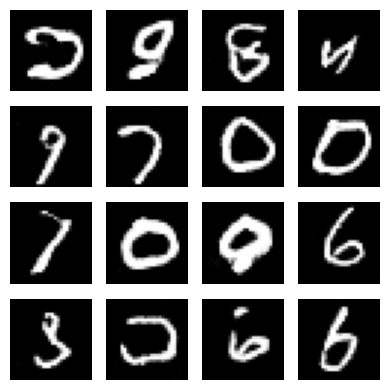

[Epoch 141/300] Loss_D: 0.2102, Loss_G: 2.9496, Time: 3956.71s
[Epoch 142/300] Loss_D: 0.2215, Loss_G: 3.0088, Time: 3976.61s
[Epoch 143/300] Loss_D: 0.2081, Loss_G: 3.0314, Time: 3997.76s
[Epoch 144/300] Loss_D: 0.2352, Loss_G: 3.0558, Time: 4016.44s
[Epoch 145/300] Loss_D: 0.2245, Loss_G: 2.9433, Time: 4035.32s
[Epoch 146/300] Loss_D: 0.2144, Loss_G: 2.9599, Time: 4054.27s
[Epoch 147/300] Loss_D: 0.2155, Loss_G: 2.9230, Time: 4074.30s
[Epoch 148/300] Loss_D: 0.2334, Loss_G: 2.9425, Time: 4094.40s
[Epoch 149/300] Loss_D: 0.2251, Loss_G: 2.9292, Time: 4115.99s
[Epoch 150/300] Loss_D: 0.2177, Loss_G: 2.9749, Time: 4138.00s
[Epoch 151/300] Loss_D: 0.2098, Loss_G: 2.9207, Time: 4158.85s
[Epoch 152/300] Loss_D: 0.2443, Loss_G: 3.0085, Time: 4179.84s
[Epoch 153/300] Loss_D: 0.2282, Loss_G: 2.9517, Time: 4199.37s
[Epoch 154/300] Loss_D: 0.2267, Loss_G: 2.9309, Time: 4218.83s
[Epoch 155/300] Loss_D: 0.2184, Loss_G: 2.9088, Time: 4238.54s
[Epoch 156/300] Loss_D: 0.2334, Loss_G: 2.9520, Time: 4

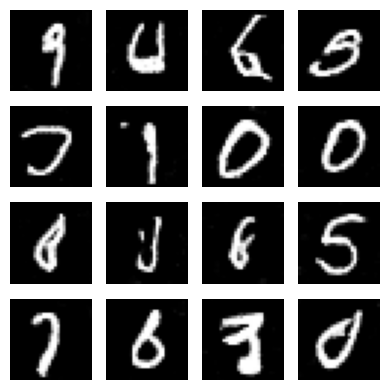

[Epoch 161/300] Loss_D: 0.2419, Loss_G: 2.9918, Time: 4363.75s
[Epoch 162/300] Loss_D: 0.2260, Loss_G: 3.0611, Time: 4383.69s
[Epoch 163/300] Loss_D: 0.2130, Loss_G: 2.8844, Time: 4402.86s
[Epoch 164/300] Loss_D: 0.2180, Loss_G: 2.9034, Time: 4422.11s
[Epoch 165/300] Loss_D: 0.2252, Loss_G: 2.9820, Time: 4441.55s
[Epoch 166/300] Loss_D: 0.2446, Loss_G: 2.9677, Time: 4461.41s
[Epoch 167/300] Loss_D: 0.2187, Loss_G: 2.9119, Time: 4481.75s
[Epoch 168/300] Loss_D: 0.2483, Loss_G: 3.0209, Time: 4503.08s
[Epoch 169/300] Loss_D: 0.2358, Loss_G: 3.0060, Time: 4524.25s
[Epoch 170/300] Loss_D: 0.2217, Loss_G: 2.8442, Time: 4544.95s
[Epoch 171/300] Loss_D: 0.2343, Loss_G: 2.8868, Time: 4565.27s
[Epoch 172/300] Loss_D: 0.2065, Loss_G: 2.8789, Time: 4584.70s
[Epoch 173/300] Loss_D: 0.2278, Loss_G: 2.9464, Time: 4604.59s
[Epoch 174/300] Loss_D: 0.2361, Loss_G: 2.9480, Time: 4623.54s
[Epoch 175/300] Loss_D: 0.2372, Loss_G: 2.8868, Time: 4642.59s
[Epoch 176/300] Loss_D: 0.2263, Loss_G: 2.9582, Time: 4

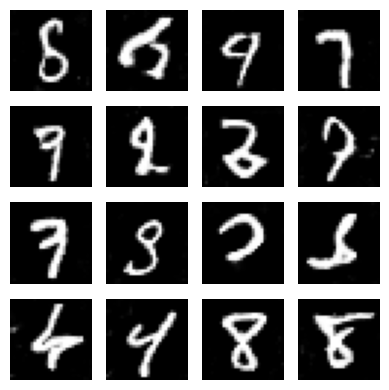

[Epoch 181/300] Loss_D: 0.2286, Loss_G: 2.9018, Time: 4763.82s
[Epoch 182/300] Loss_D: 0.2318, Loss_G: 2.8987, Time: 4783.57s
[Epoch 183/300] Loss_D: 0.2262, Loss_G: 3.0321, Time: 4803.09s
[Epoch 184/300] Loss_D: 0.2308, Loss_G: 2.9314, Time: 4822.19s
[Epoch 185/300] Loss_D: 0.2287, Loss_G: 2.9120, Time: 4844.26s
[Epoch 186/300] Loss_D: 0.2420, Loss_G: 2.9883, Time: 4865.30s
[Epoch 187/300] Loss_D: 0.2494, Loss_G: 2.9811, Time: 4886.73s
[Epoch 188/300] Loss_D: 0.2215, Loss_G: 2.8462, Time: 4907.47s
[Epoch 189/300] Loss_D: 0.2276, Loss_G: 2.9470, Time: 4927.70s
[Epoch 190/300] Loss_D: 0.2122, Loss_G: 2.9056, Time: 4947.65s
[Epoch 191/300] Loss_D: 0.2565, Loss_G: 3.0109, Time: 4966.88s
[Epoch 192/300] Loss_D: 0.2276, Loss_G: 2.8692, Time: 4985.01s
[Epoch 193/300] Loss_D: 0.2377, Loss_G: 2.9842, Time: 5003.92s
[Epoch 194/300] Loss_D: 0.2190, Loss_G: 2.8810, Time: 5024.54s
[Epoch 195/300] Loss_D: 0.2227, Loss_G: 2.9070, Time: 5046.02s
[Epoch 196/300] Loss_D: 0.2452, Loss_G: 2.9419, Time: 5

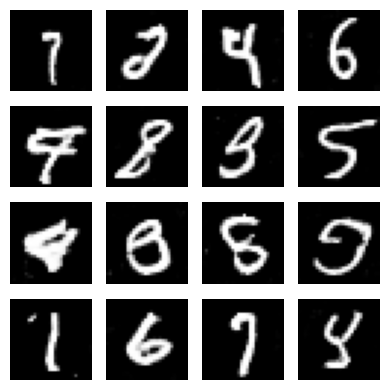

[Epoch 201/300] Loss_D: 0.2184, Loss_G: 2.8942, Time: 5165.35s
[Epoch 202/300] Loss_D: 0.2309, Loss_G: 2.9319, Time: 5184.84s
[Epoch 203/300] Loss_D: 0.2476, Loss_G: 2.9877, Time: 5205.45s
[Epoch 204/300] Loss_D: 0.2191, Loss_G: 2.8944, Time: 5225.85s
[Epoch 205/300] Loss_D: 0.2379, Loss_G: 2.9515, Time: 5246.45s
[Epoch 206/300] Loss_D: 0.2362, Loss_G: 2.9198, Time: 5267.01s
[Epoch 207/300] Loss_D: 0.2188, Loss_G: 2.9182, Time: 5287.80s
[Epoch 208/300] Loss_D: 0.2381, Loss_G: 2.9983, Time: 5307.46s
[Epoch 209/300] Loss_D: 0.2184, Loss_G: 2.9304, Time: 5328.21s
[Epoch 210/300] Loss_D: 0.2318, Loss_G: 2.9787, Time: 5347.36s
[Epoch 211/300] Loss_D: 0.2474, Loss_G: 3.0590, Time: 5367.00s
[Epoch 212/300] Loss_D: 0.2319, Loss_G: 2.9124, Time: 5386.93s
[Epoch 213/300] Loss_D: 0.2303, Loss_G: 2.9437, Time: 5406.88s
[Epoch 214/300] Loss_D: 0.2301, Loss_G: 2.9650, Time: 5427.11s
[Epoch 215/300] Loss_D: 0.2435, Loss_G: 2.9647, Time: 5447.93s
[Epoch 216/300] Loss_D: 0.2303, Loss_G: 2.9129, Time: 5

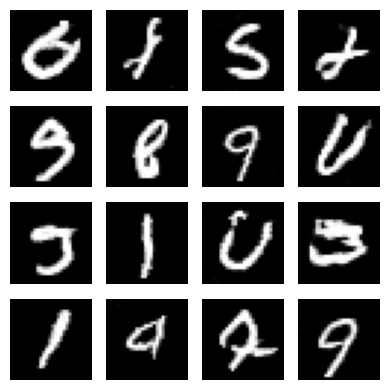

[Epoch 221/300] Loss_D: 0.2089, Loss_G: 2.9846, Time: 5565.56s
[Epoch 222/300] Loss_D: 0.2217, Loss_G: 2.9625, Time: 5585.14s
[Epoch 223/300] Loss_D: 0.2050, Loss_G: 3.0000, Time: 5605.20s
[Epoch 224/300] Loss_D: 0.2254, Loss_G: 2.9826, Time: 5625.86s
[Epoch 225/300] Loss_D: 0.2457, Loss_G: 3.1626, Time: 5644.96s
[Epoch 226/300] Loss_D: 0.2352, Loss_G: 3.0657, Time: 5662.50s
[Epoch 227/300] Loss_D: 0.2214, Loss_G: 2.9550, Time: 5680.84s
[Epoch 228/300] Loss_D: 0.2073, Loss_G: 2.9477, Time: 5699.41s
[Epoch 229/300] Loss_D: 0.2422, Loss_G: 2.9872, Time: 5717.02s
[Epoch 230/300] Loss_D: 0.2187, Loss_G: 3.0367, Time: 5735.86s
[Epoch 231/300] Loss_D: 0.2236, Loss_G: 2.9736, Time: 5755.76s
[Epoch 232/300] Loss_D: 0.2130, Loss_G: 3.0686, Time: 5775.11s
[Epoch 233/300] Loss_D: 0.2120, Loss_G: 2.9454, Time: 5793.62s
[Epoch 234/300] Loss_D: 0.2483, Loss_G: 3.0256, Time: 5813.09s
[Epoch 235/300] Loss_D: 0.2003, Loss_G: 3.0664, Time: 5830.86s
[Epoch 236/300] Loss_D: 0.2231, Loss_G: 3.0045, Time: 5

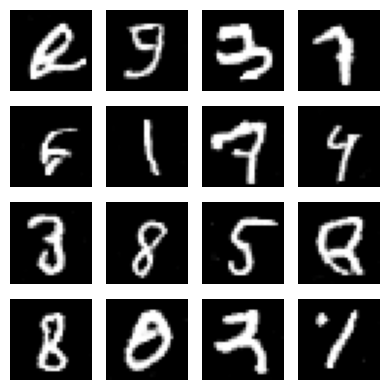

[Epoch 241/300] Loss_D: 0.2255, Loss_G: 3.0388, Time: 5941.85s
[Epoch 242/300] Loss_D: 0.2147, Loss_G: 2.9914, Time: 5961.41s
[Epoch 243/300] Loss_D: 0.2046, Loss_G: 3.0322, Time: 5981.28s
[Epoch 244/300] Loss_D: 0.2135, Loss_G: 3.0745, Time: 6000.34s
[Epoch 245/300] Loss_D: 0.2276, Loss_G: 3.0797, Time: 6019.43s
[Epoch 246/300] Loss_D: 0.2285, Loss_G: 3.0326, Time: 6038.66s
[Epoch 247/300] Loss_D: 0.2214, Loss_G: 2.9824, Time: 6053.97s
[Epoch 248/300] Loss_D: 0.2171, Loss_G: 3.0616, Time: 6091.49s
[Epoch 249/300] Loss_D: 0.2210, Loss_G: 3.0262, Time: 6140.31s
[Epoch 250/300] Loss_D: 0.2161, Loss_G: 3.0596, Time: 6188.09s
[Epoch 251/300] Loss_D: 0.2205, Loss_G: 3.0797, Time: 6235.05s
[Epoch 252/300] Loss_D: 0.2208, Loss_G: 3.0623, Time: 6282.44s
[Epoch 253/300] Loss_D: 0.2514, Loss_G: 3.0407, Time: 6328.48s
[Epoch 254/300] Loss_D: 0.2168, Loss_G: 3.0111, Time: 6375.28s
[Epoch 255/300] Loss_D: 0.1988, Loss_G: 3.0567, Time: 6423.87s
[Epoch 256/300] Loss_D: 0.2056, Loss_G: 3.0284, Time: 6

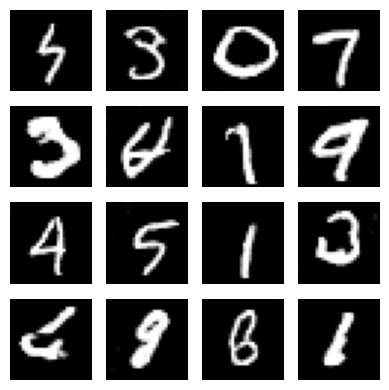

[Epoch 261/300] Loss_D: 0.2262, Loss_G: 3.0565, Time: 6699.09s
[Epoch 262/300] Loss_D: 0.2110, Loss_G: 3.0324, Time: 6744.50s
[Epoch 263/300] Loss_D: 0.2261, Loss_G: 3.0788, Time: 6782.46s
[Epoch 264/300] Loss_D: 0.2172, Loss_G: 3.0530, Time: 6827.08s
[Epoch 265/300] Loss_D: 0.2258, Loss_G: 3.0478, Time: 6862.79s
[Epoch 266/300] Loss_D: 0.2137, Loss_G: 3.1113, Time: 6904.14s
[Epoch 267/300] Loss_D: 0.2107, Loss_G: 3.0636, Time: 6945.33s
[Epoch 268/300] Loss_D: 0.2334, Loss_G: 3.1140, Time: 6987.24s
[Epoch 269/300] Loss_D: 0.2176, Loss_G: 3.0804, Time: 7026.85s
[Epoch 270/300] Loss_D: 0.2076, Loss_G: 3.1059, Time: 7067.39s
[Epoch 271/300] Loss_D: 0.2131, Loss_G: 3.0059, Time: 7107.52s
[Epoch 272/300] Loss_D: 0.2106, Loss_G: 3.0564, Time: 7147.11s
[Epoch 273/300] Loss_D: 0.2208, Loss_G: 3.1590, Time: 7191.95s
[Epoch 274/300] Loss_D: 0.2277, Loss_G: 3.1533, Time: 7237.88s
[Epoch 275/300] Loss_D: 0.2073, Loss_G: 3.1090, Time: 7281.95s
[Epoch 276/300] Loss_D: 0.2505, Loss_G: 3.2152, Time: 7

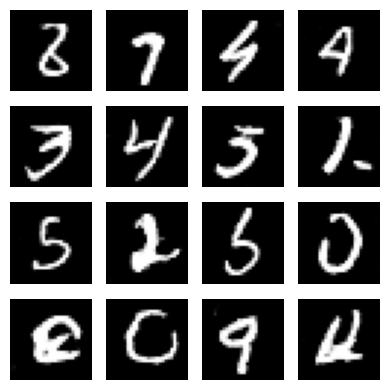

[Epoch 281/300] Loss_D: 0.2225, Loss_G: 3.0961, Time: 7558.20s
[Epoch 282/300] Loss_D: 0.2265, Loss_G: 3.1302, Time: 7606.27s
[Epoch 283/300] Loss_D: 0.2279, Loss_G: 3.1240, Time: 7650.63s
[Epoch 284/300] Loss_D: 0.2069, Loss_G: 3.0945, Time: 7698.28s
[Epoch 285/300] Loss_D: 0.2120, Loss_G: 3.1659, Time: 7744.99s
[Epoch 286/300] Loss_D: 0.2208, Loss_G: 3.1371, Time: 7791.35s
[Epoch 287/300] Loss_D: 0.2244, Loss_G: 3.1995, Time: 7838.34s
[Epoch 288/300] Loss_D: 0.2074, Loss_G: 3.2197, Time: 7885.36s
[Epoch 289/300] Loss_D: 0.2210, Loss_G: 3.1306, Time: 7918.25s
[Epoch 290/300] Loss_D: 0.2160, Loss_G: 3.1454, Time: 7946.75s
[Epoch 291/300] Loss_D: 0.2126, Loss_G: 3.0843, Time: 7968.94s
[Epoch 292/300] Loss_D: 0.2155, Loss_G: 3.1708, Time: 7988.63s
[Epoch 293/300] Loss_D: 0.2146, Loss_G: 3.1456, Time: 8035.97s
[Epoch 294/300] Loss_D: 0.2058, Loss_G: 3.1540, Time: 8059.97s
[Epoch 295/300] Loss_D: 0.2360, Loss_G: 3.1333, Time: 8081.27s
[Epoch 296/300] Loss_D: 0.2093, Loss_G: 3.0489, Time: 8

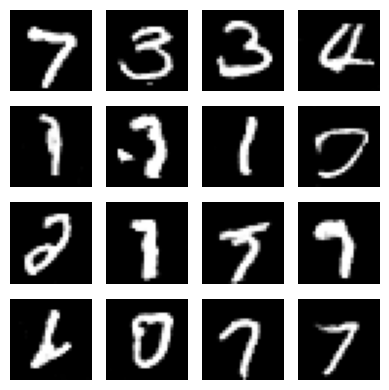

In [25]:
# ----- Training loop-----
t0 = time.perf_counter()
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)

        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)  # generator returns (b,1,28,28)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.tight_layout()
            plt.show()

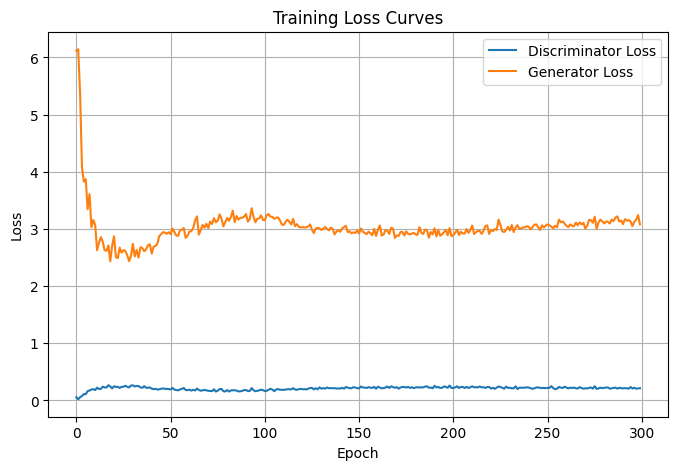

In [28]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

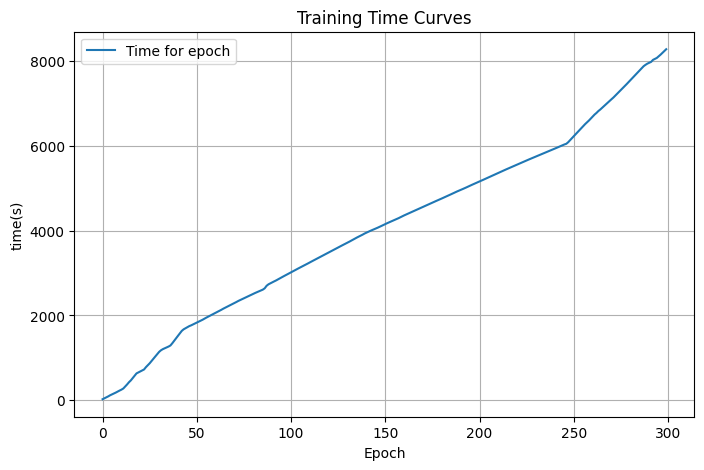

In [29]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [30]:
# Export to CSV
csv_file = 'DCGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to DCGAN_training_history.csv


Đang sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU
[Epoch 1/300] Loss_D: 0.0612, Loss_G: 5.6930, Time: 25.58s


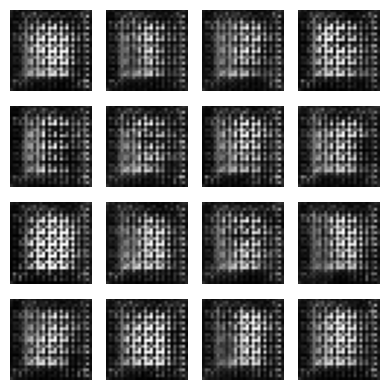

KeyboardInterrupt: 

In [ ]:
# dcgan_mnist_simple.py
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

# ----- Cấu hình (kept from your GAN.txt) -----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0004
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 64

# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # single-channel normalize
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)





# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}



# ----- Plot loss curves -----
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history['loss_D']) + 1), history['loss_D'], label='Discriminator Loss')
plt.plot(range(1, len(history['loss_G']) + 1), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

# ----- Export to CSV -----
csv_file = 'DCGAN_MNIST_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(1, history['epoch'] + 1), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")
